# Activation Functions

the activation is what makes a neural net non-linear. without it, stacking layers does nothing, the whole net collapses into one linear model. heres the common ones and why we pick each.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## why we even need them

quick proof, two linear layers with nothing in between is just a single linear layer.

In [2]:
np.random.seed(0)
W1 = np.random.randn(2, 3)
W2 = np.random.randn(3, 1)
x = np.random.randn(5, 2)

two_layers = (x @ W1) @ W2
one_layer = x @ (W1 @ W2)        # same thing, collapsed into one matrix
print("two linear layers == one linear layer:", np.allclose(two_layers, one_layer))

two linear layers == one linear layer: True


True. so no matter how many linear layers you stack its still a straight line. the activation sitting between layers is what breaks that and lets the net bend.

## the common ones

- **sigmoid** : squashes to (0, 1), used for a binary output
- **tanh** : squashes to (-1, 1), zero centered, was popular for hidden layers
- **relu** : max(0, z), the default for hidden layers now
- **leaky relu** : like relu but a small slope for negatives so neurons dont fully die

In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def tanh(z):
    return np.tanh(z)

def relu(z):
    return np.maximum(0, z)

def leaky_relu(z, a=0.01):
    return np.where(z > 0, z, a * z)

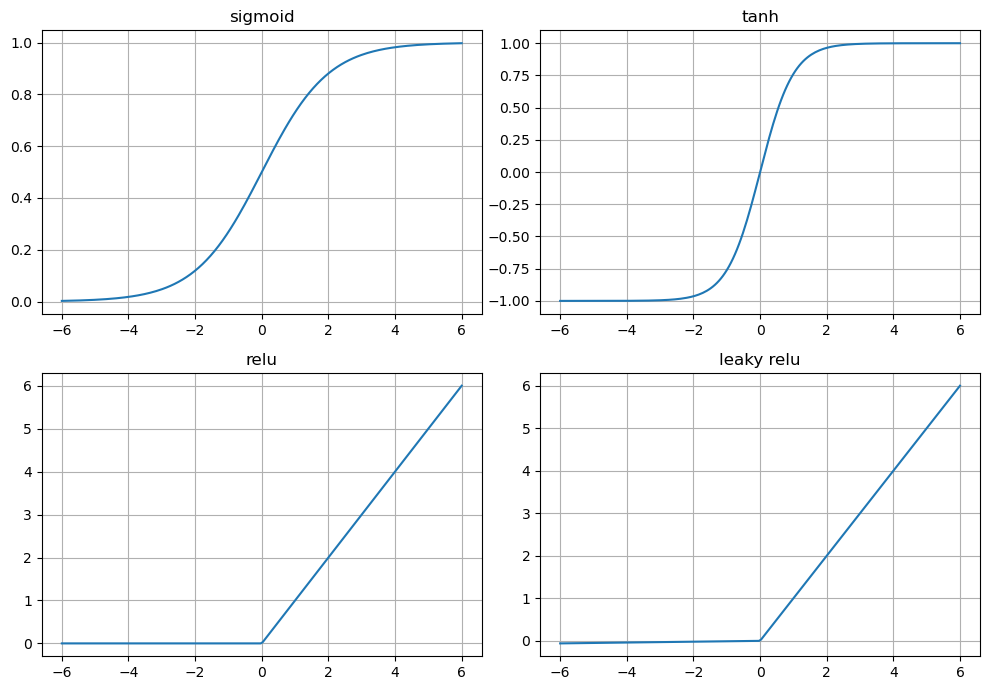

In [10]:
z = np.linspace(-6, 6, 200)

fig, ax = plt.subplots(2, 2, figsize=(10, 7))
ax[0, 0].plot(z, sigmoid(z)); ax[0, 0].set_title("sigmoid"); ax[0, 0].grid(True)
ax[0, 1].plot(z, tanh(z)); ax[0, 1].set_title("tanh"); ax[0, 1].grid(True)
ax[1, 0].plot(z, relu(z)); ax[1, 0].set_title("relu"); ax[1, 0].grid(True)
ax[1, 1].plot(z, leaky_relu(z)); ax[1, 1].set_title("leaky relu"); ax[1, 1].grid(True)
plt.tight_layout(); plt.show()

## their derivatives

backprop needs the slope of each activation, so heres the derivatives too.

In [5]:
def d_sigmoid(z):
    s = sigmoid(z)
    return s * (1 - s)

def d_tanh(z):
    return 1 - np.tanh(z) ** 2

def d_relu(z):
    return (z > 0).astype(float)

def d_leaky(z, a=0.01):
    return np.where(z > 0, 1.0, a)

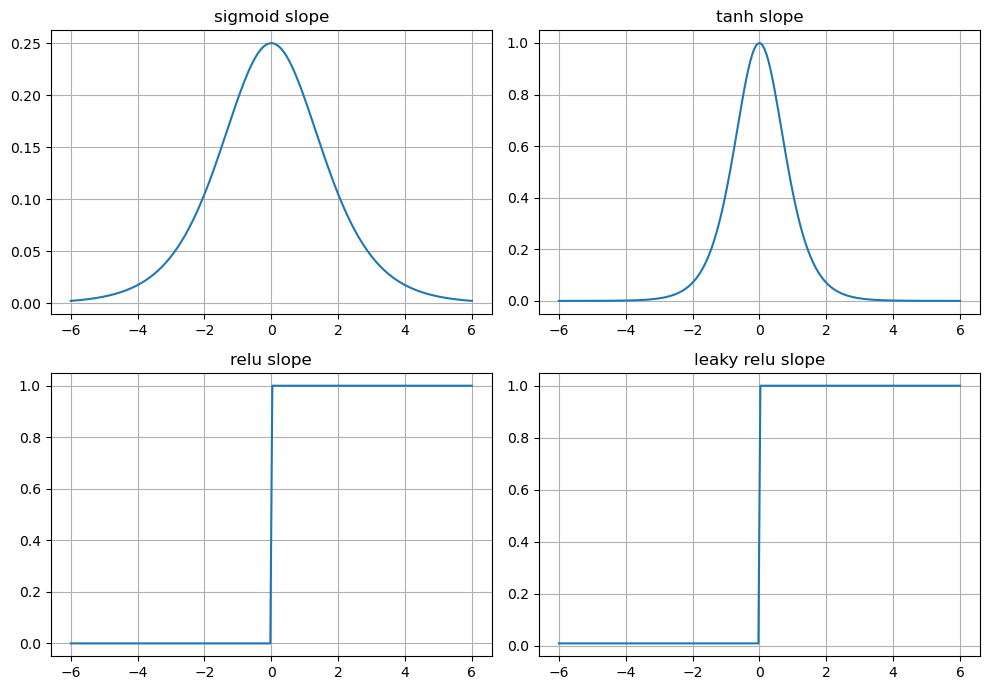

In [6]:
fig, ax = plt.subplots(2, 2, figsize=(10, 7))
ax[0, 0].plot(z, d_sigmoid(z)); ax[0, 0].set_title("sigmoid slope"); ax[0, 0].grid(True)
ax[0, 1].plot(z, d_tanh(z)); ax[0, 1].set_title("tanh slope"); ax[0, 1].grid(True)
ax[1, 0].plot(z, d_relu(z)); ax[1, 0].set_title("relu slope"); ax[1, 0].grid(True)
ax[1, 1].plot(z, d_leaky(z)); ax[1, 1].set_title("leaky relu slope"); ax[1, 1].grid(True)
plt.tight_layout(); plt.show()

## the vanishing gradient problem

notice sigmoid and tanh go flat (slope near 0) when z is big or small, theyre saturated. in backprop you multiply these slopes through every layer, so in a deep net the gradient shrinks to almost nothing and the early layers stop learning. relu's slope is just 1 for positive z, so it doesnt vanish. thats the main reason relu became the default.

In [7]:
# the sigmoid slope never even goes above 0.25
print("max sigmoid slope:", round(d_sigmoid(z).max(), 3))
print("max tanh slope   :", round(d_tanh(z).max(), 3))
print("max relu slope   :", round(d_relu(z).max(), 3))

max sigmoid slope: 0.25
max tanh slope   : 0.999
max relu slope   : 1.0


so every sigmoid layer can cut the gradient by 4x or more, stack a few and its gone. relu keeps it at 1, nothing shrinks.

## softmax for the output

for a multiclass output we use softmax, it turns a vector of raw scores into probabilities that add up to 1.

In [8]:
def softmax(z):
    e = np.exp(z - z.max())     # minus max for numerical stability
    return e / e.sum()

scores = np.array([2.0, 1.0, 0.1])
print("probabilities:", softmax(scores).round(3))
print("sum:", softmax(scores).sum())

probabilities: [0.659 0.242 0.099]
sum: 1.0


## does the choice actually matter

on a small shallow net they all do fine, lets check on moons. the real gap shows up in deep nets where the vanishing gradient actually bites.

In [9]:
from sklearn.datasets import make_moons
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split

X, y = make_moons(n_samples=300, noise=0.2, random_state=42)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=42)

for act in ['logistic', 'tanh', 'relu']:
    m = MLPClassifier(hidden_layer_sizes=(16,), activation=act, max_iter=3000, random_state=1)
    m.fit(Xtr, ytr)
    print(f'{act:9} test acc: {m.score(Xte, yte):.3f}')

logistic  test acc: 0.900
tanh      test acc: 0.900
relu      test acc: 0.889


so the activation is where a net gets its power. relu for the hidden layers (no vanishing gradient), sigmoid or softmax at the output depending on binary vs multiclass. next i'll train the network on some real datasets.